Pytorch Version: 2.13.0+cpu


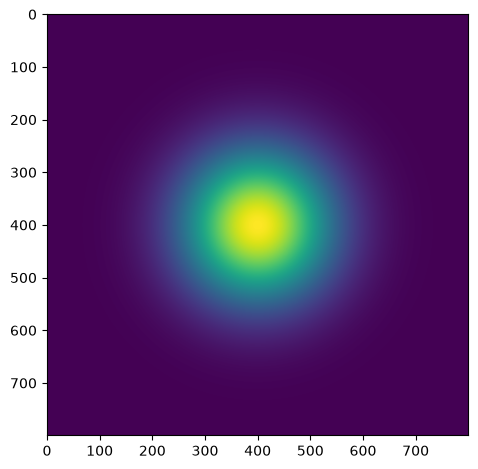

In [18]:
# 1.1
import torch
import numpy as np

print("Pytorch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

x = torch.Tensor(X)
y = torch.Tensor(Y)

x = x.to(device)
y = y.to(device)

z = torch.exp(-(x**2 + y**2)/2.0)

import matplotlib.pyplot as plt

plt.imshow(z.cpu().numpy())# Updated !

plt.tight_layout()
plt.show()

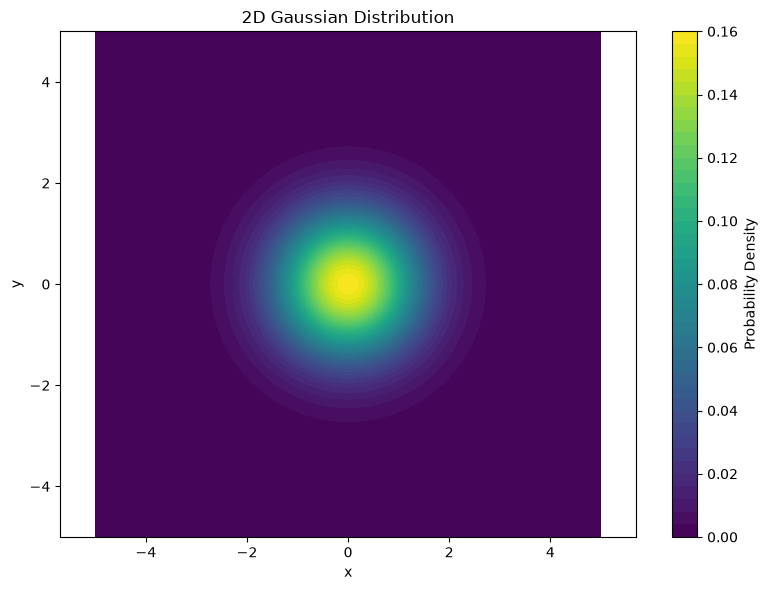

In [ ]:
# 1.2
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu_x, mu_y = 0.0, 0.0      # Mean
sigma_x, sigma_y = 1.0, 1.0  # Standard deviations

# Create a grid of points
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

# Compute the 2D Gaussian
Z = (
    1 / (2 * np.pi * sigma_x * sigma_y)
    * np.exp(
        -(
            ((X - mu_x) ** 2) / (2 * sigma_x ** 2)
            + ((Y - mu_y) ** 2) / (2 * sigma_y ** 2)
        )
    )
)

# Plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50)
plt.colorbar(contour, label="Probability Density")
plt.title("2D Gaussian Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

### 1. Generate 2D Gaussian (Numpy)
**Prompt:** "Generate a Python script to plot a 2D Gaussian function using Numpy and Matplotlib"

**Result:** Worked first try. Produced a normalized 2D Gaussian PDF (peak ≈ 0.159) with axis labels and a colorbar, versus my own unnormalized version from the lab sheet (peak = 1.0, using `torch.exp(-(x**2+y**2)/2.0)`). I identified this scaling difference as a deliberate, valid choice by the AI (proper probability density normalization) rather than an error. Also noticed a minor `contourf` edge-rendering artifact near the plot boundary — cosmetic only, not fixed.

Using device: cpu


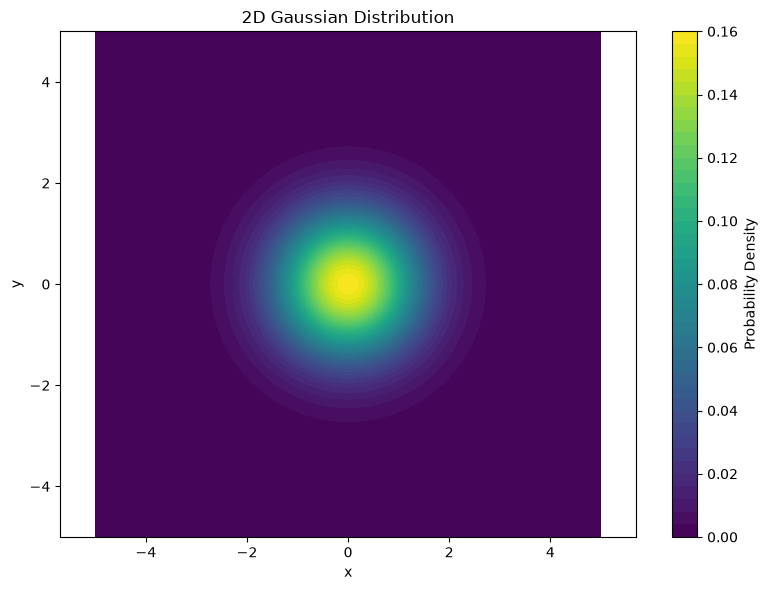

In [4]:
# 1.2
import torch
import matplotlib.pyplot as plt

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parameters
mu_x, mu_y = 0.0, 0.0
sigma_x, sigma_y = 1.0, 1.0

# Create grid directly on the selected device
x = torch.linspace(-5, 5, 200, device=device)
y = torch.linspace(-5, 5, 200, device=device)

X, Y = torch.meshgrid(x, y, indexing="xy")

# Compute the 2D Gaussian
Z = (
    1 / (2 * torch.pi * sigma_x * sigma_y)
    * torch.exp(
        -(
            ((X - mu_x) ** 2) / (2 * sigma_x ** 2)
            + ((Y - mu_y) ** 2) / (2 * sigma_y ** 2)
        )
    )
)

# Move tensors back to CPU for Matplotlib
X_cpu = X.cpu()
Y_cpu = Y.cpu()
Z_cpu = Z.cpu()

# Plot
plt.figure(figsize=(8, 6))

contour = plt.contourf(
    X_cpu,
    Y_cpu,
    Z_cpu,
    levels=50
)

plt.colorbar(contour, label="Probability Density")
plt.title("2D Gaussian Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

### 2. Convert Gaussian script to PyTorch
**Prompt:** "Convert this script to use PyTorch tensors instead of Numpy arrays, and run on GPU if available"

**Result:** Worked first try. Rebuilt the coordinate grid using `torch.linspace` + `torch.meshgrid` directly on `device`, instead of building it in Numpy first and copying it over afterward (the lab sheet's `mgrid` approach) — this is more efficient since it avoids an unnecessary CPU→GPU transfer. Kept the same normalized PDF formula as its previous answer. Compared this against my own `mgrid`-based version from the lab sheet: both are mathematically correct, and differ only in normalization convention and grid-construction method.

Using device: cpu


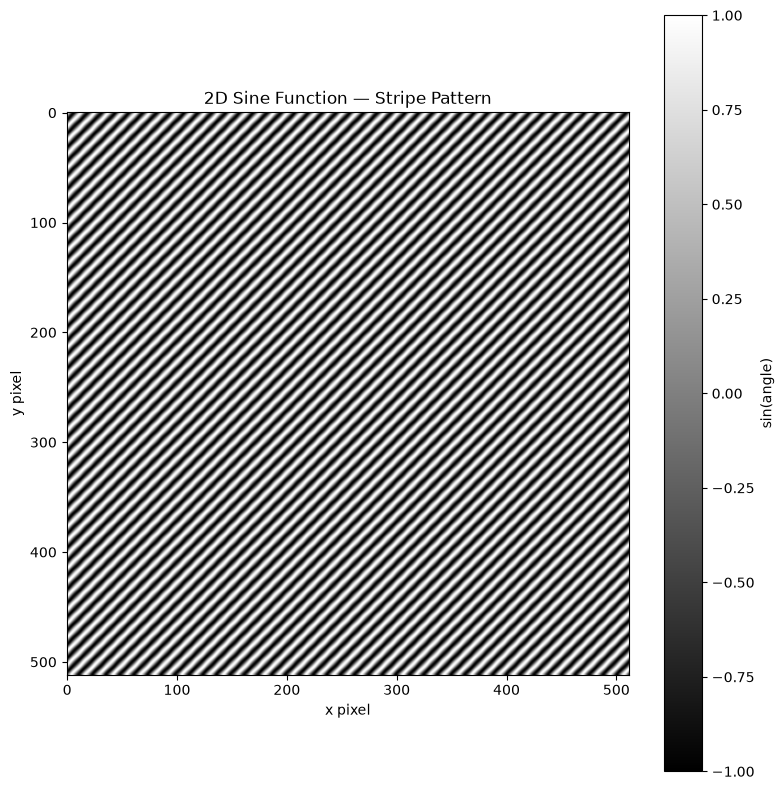

In [4]:
# 1.2
import torch
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Image dimensions
height = 512
width = 512

# Create pixel-coordinate grids
y = torch.arange(height, device=device)
x = torch.arange(width, device=device)

X, Y = torch.meshgrid(x, y, indexing="xy")

# Controls the stripe frequency and direction
kx = 0.5
ky = 0.5

# Angle depends on BOTH x and y coordinates
angle = kx * X + ky * Y

# Apply sine
Z = torch.cos(angle)

# Move result to CPU for Matplotlib
Z_cpu = Z.cpu()

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(
    Z_cpu,
    cmap="gray",
    origin="upper"
)

plt.title("2D Sine Function — Stripe Pattern")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.colorbar(label="sin(angle)")
plt.tight_layout()
plt.show()

### 3. Generate 2D sine function (linear/diagonal)
**Prompt:** "Using PyTorch, create a 2D sine function where the sine's angle depends on both x and y pixel coordinates, and plot it to show stripe patterns"

**Result:** Worked first try. Produced diagonal stripes using `angle = kx*X + ky*Y` (a linear combination of x and y), with `kx = ky = 0.1` controlling stripe frequency and direction. I confirmed this linear form is the correct interpretation to use for the Gabor filter step, since real Gabor filters use oriented/directional sinusoids, not radial ripples.

Using device: cpu


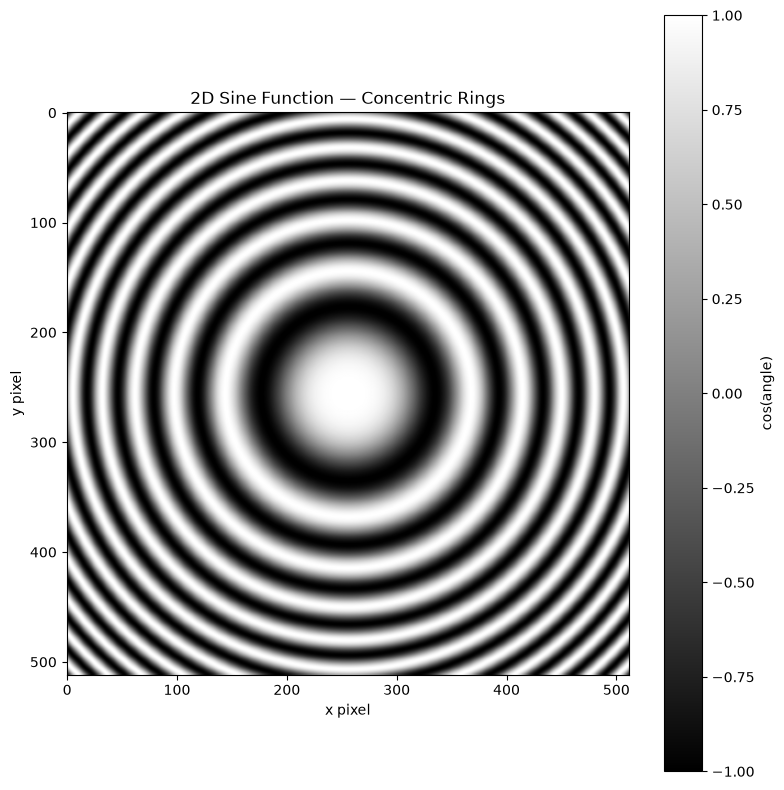

In [7]:
# 1.3 x**2 + y**2 sine function
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

height = 512
width = 512

# Centre the pixel coordinates on zero, instead of 0..512
y = torch.arange(height, device=device) - height // 2
x = torch.arange(width, device=device) - width // 2

X, Y = torch.meshgrid(x, y, indexing="xy")

# Small scale factor keeps the local frequency below the Nyquist limit everywhere
k = 0.0005

# Angle depends on BOTH x and y coordinates (radial distance squared)
angle = k * (X**2 + Y**2)

# Apply sine
Z = torch.cos(angle)

Z_cpu = Z.cpu()

plt.figure(figsize=(8, 8))
plt.imshow(Z_cpu, cmap="gray", origin="upper")
plt.title("2D Sine Function — Concentric Rings")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.colorbar(label="cos(angle)")
plt.tight_layout()
plt.show()

### 4. Generate 2D sine function (radial/concentric rings)
**Prompt:** "Using PyTorch, create a 2D sine function where the sine's angle depends on both x and y pixel coordinates, and plot it to show concentric rings patterns"

**Result:** The AI gave `sqrt((X - cx)**2 + (Y - cy)**2)` as the angle — not exactly the form I wanted. I worked out myself that using `X**2 + Y**2` directly (without the square root) was the right formula, then diagnosed and fixed a separate aliasing problem on my own: the raw pixel-index grid (0–512, uncentred) caused the local frequency of `sin(x²+y²)` to exceed the Nyquist sampling limit near the image edges, producing a checkerboard/moiré pattern instead of clean rings. Fixed by centring the coordinate grid on zero (`- height//2`) and scaling the angle by a small constant (`k = 0.0005`) to keep the oscillation frequency low enough to be represented correctly across the whole image.

Pytorch Version: 2.13.0+cpu


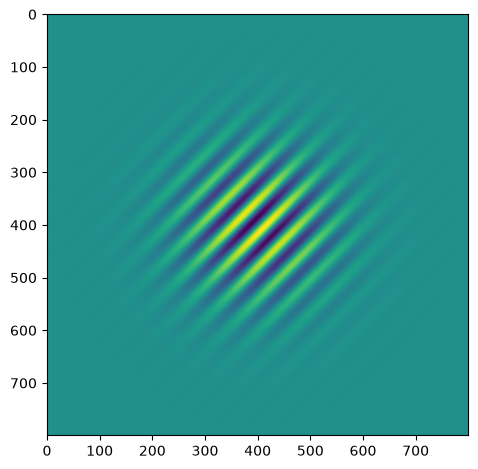

In [1]:
# Gabor filter
import torch
import numpy as np

print("Pytorch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

height = 800
width = 800

x = torch.Tensor(X)
y = torch.Tensor(Y)

x = x.to(device)
y = y.to(device)

z = torch.exp(-(x**2 + y**2)/2.0)

# Create pixel-coordinate grids
y_sine = torch.arange(height, device=device)
x_sine = torch.arange(width, device=device)

X_sine, Y_sine = torch.meshgrid(x_sine, y_sine, indexing="xy")

# Controls the stripe frequency and direction
kx = 0.1
ky = 0.1

# Angle depends on BOTH x and y coordinates
angle = kx * X_sine + ky * Y_sine

# Apply sine
z_sine = torch.cos(angle)

gabor = z * z_sine

import matplotlib.pyplot as plt

plt.imshow(gabor.cpu().numpy())# Updated !

plt.tight_layout()
plt.show()

### 5. Gabor filter (Gaussian × sine)
**Not AI-generated.** Built myself by multiplying the Gaussian (`z`) and sine (`z_sine`) tensors elementwise. Verified both tensors were the same shape (800×800) before multiplying, to avoid a silent broadcasting error. Result shows correctly localized, oriented fringes consistent with a Gabor filter / mammalian receptive field model, as described in the lab sheet.